# 2.9b — GenEFT : une théorie effective de la généralisation

**Navigation** : [<< 2.9-Grokking](2.9-Grokking-Generalisation.ipynb) | [2.10-Optimisation-Hyperparametres >>](2.10-Optimisation-Hyperparametres.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook [2.9](2.9-Grokking-Generalisation.ipynb) a *montré* le grokking : un réseau mémorise d'abord, généralise avec un long retard, et le weight-decay est le levier qui déclenche la bascule. Mais ce notebook restait descriptif — **pourquoi** ces transitions arrivent-elles, et peut-on les *prédire* ?

Ce notebook présente **GenEFT** (Baek, Liu & Tegmark 2024) : une **théorie effective** de la généralisation, dans l'esprit de la physique statistique. Une théorie *effective* ne prétend pas décrire tous les neurones : elle identifie les **petites quantités observables** qui gouvernent la phénoménologie, puis prédit leurs lois. GenEFT répond à deux questions, chacune avec ses propres observables :

1. **Statics** — *combien de données au minimum ?* L'observable est la **longueur de description** $b$ de la relation à apprendre (en bits). Elle fixe une **fraction critique** $p_c$ d'échantillons en dessous de laquelle aucune généralisation n'est possible.
2. **Dynamics** — *avec quels taux d'apprentissage ?* Les représentations sont modélisées comme des particules — les **« repons »** — dont les équations de mouvement prédisent une **frontière arctan** entre mémorisation et généralisation, qui ne dépend que du **ratio** des learning rates encodeur/décodeur.

**Pourquoi une accrétion « b » de 2.9.** Le parent a établi le *constat expérimental* (le grokking existe, le weight-decay le déclenche) ; ce notebook apporte la *théorie effective* qui l'explique et qui prédit ses transitions. Le lien est direct : la référence théorique du grokking (Liu et al. 2022) est déjà citée par le 2.9, et GenEFT la prolonge.

**Plan.** Sections 1 à 3 : la partie *statics* (bits, boules dans les seaux, borne supérieure). Sections 4 à 7 : les expériences réseau qui la confrontent (gap inductif, zone Goldilocks, clusters). Sections 8 à 10 : la partie *dynamics* (théorème des repons, quantité conservée, frontière arctan, diagramme de phase). Trois exercices ferment le notebook.

> **Référence.** Baek, J.-S., Liu, Z. & Tegmark, M. (2024). *Towards Understanding Generalization via Effective Statistics of Random Data*. arXiv:2402.05916. — Le papier dont ce notebook reproduit les expériences principales sur un graphe de connaissances à $n = 30$ symboles, exécutable en quelques minutes sur CPU.

In [1]:
# Configuration et imports pour le notebook 2.9b
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from math import log2, log10, factorial, comb

%matplotlib inline

# Reproductibilite
torch.manual_seed(0)
np.random.seed(0)
RNG = np.random.default_rng(0)
torch.set_num_threads(4)

# Parametres canoniques de GenEFT (Baek, Liu & Tegmark 2024, Table III)
N_SYMBOLS = 30      # nombre de symboles du graphe de connaissances
DIM = 2             # dimension de l'espace d'embedding
LR = 1e-3           # taux d'apprentissage (Adam)
FRACTION = 0.75     # fraction des n^2 paires montreee a l'entrainement
DEPTH = 3           # profondeur du decodeur MLP
WIDTH = 50          # largeur du decodeur MLP
ALPHA = 0.9         # seuil d'exactitude pour la fraction critique pc
A_BIPARTI = 10      # taille de l'ensemble S du graphe biparti complet

print(f"Imports OK : torch {torch.__version__}")
print(f"Graphe : n = {N_SYMBOLS} symboles, N = {N_SYMBOLS**2} paires | "
      f"embedding {DIM}D | decodeur {DEPTH}x{WIDTH} tanh")

Imports OK : torch 2.13.0+cu126
Graphe : n = 30 symboles, N = 900 paires | embedding 2D | decodeur 3x50 tanh


## 1. Combien de bits contient une relation ?

Apprendre une relation binaire $R$ sur $n$ symboles, c'est remplir une matrice $n \times n$ de 0 et de 1. Pour une relation **générique** (aucune propriété), il faut spécifier chaque entrée : $b = n^2$ bits. Mais la plupart des relations utiles ont des **propriétés logiques** — symétrie, réflexivité, transitivité — qui rendent certaines entrées *déductibles* des autres : les décrire coûte moins de bits.

GenEFT mesure ce coût par la **longueur de description**

$$b = \log_2 \frac{n!}{|\mathrm{Aut}(G)|}$$

où $|\mathrm{Aut}(G)|$ compte les symétries du graphe $G$ de la relation : plus le graphe est symétrique, moins il faut de bits pour le décrire. La Table II du papier donne les valeurs pour les familles usuelles :

| Relation | Longueur de description $b$ |
|---|---|
| Générique | $n^2$ |
| Symétrique | $n(n+1)/2$ |
| Équivalence à $k$ classes | $\approx n \log_2 k$ |
| Ordre total | $\log_2 n! \approx n \log_2(n/e)$ |
| Graphe biparti complet | $\approx \log_2 \binom{n}{a}$ |

Calculons $b$ pour les quatre relations qui serviront d'expérience pivot tout au long du notebook : *modulo 3*, *modulo 5*, *greater-than* et *biparti complet*.

In [2]:
n = N_SYMBOLS

def b_generique(n):
    return float(n ** 2)

def b_symetrique(n):
    return float(n * (n + 1) // 2)

def b_equivalence(n, k):
    return n * log2(k)

def b_ordre_total(n):
    return log2(factorial(n))

def b_biparti_complet(n, a):
    return log2(comb(n, a))

# Les quatre relations pivot du papier (Table I) + deux familles de reference
relations_bits = {
    "Generique (aucune propriete)": b_generique(n),
    "Symetrique":                   b_symetrique(n),
    "Equivalence mod 3":            b_equivalence(n, 3),
    "Equivalence mod 5":            b_equivalence(n, 5),
    "Ordre total (greater-than)":   b_ordre_total(n),
    "Biparti complet (a=10)":       b_biparti_complet(n, A_BIPARTI),
}

print(f"{'Relation':32s} {'b [bits]':>10s} {'b/n^2':>8s}")
print("-" * 52)
for nom, b in relations_bits.items():
    print(f"{nom:32s} {b:10.1f} {b / n**2:8.3f}")

Relation                           b [bits]    b/n^2
----------------------------------------------------
Generique (aucune propriete)          900.0    1.000
Symetrique                            465.0    0.517
Equivalence mod 3                      47.5    0.053
Equivalence mod 5                      69.7    0.077
Ordre total (greater-than)            107.7    0.120
Biparti complet (a=10)                 24.8    0.028


### Lecture du résultat

L'écart est massif : à $n = 30$, décrire l'ordre total coûte $\log_2 30! \approx 107{,}7$ bits — plus que les $n^2 = 900$ bits d'une relation générique n'en laisseraient croître... non : près de **9 fois moins** que $n^2$, mais **4 fois plus** que le biparti complet ($\log_2 \binom{30}{10} \approx 24{,}8$ bits). L'équivalence mod 3 ($\approx 47{,}5$ bits) et mod 5 ($\approx 69{,}7$ bits) s'intercalent.

L'intuition de la formule : une relation d'équivalence à $k$ classes est entièrement décrite par l'appartenance de chacun des $n$ symboles, soit $n \log_2 k$ bits ; un ordre total par la position de chaque symbole dans l'ordre, soit $\log_2 n!$ ; un biparti complet par les $a$ membres de $S$, soit $\log_2 \binom{n}{a}$.

Cette quantité $b$ va jouer le rôle de **thermomètre informationnel** : plus $b$ est grand, plus il faudra de données pour généraliser. La suite du notebook rend cette affirmation quantitative.

## 2. Boules dans les seaux : la fraction critique $p_c$

Combien d'échantillons $m$ faut-il pour connaître la relation ? En approximation crude, chaque paire d'entraînement apporte **au plus un bit** d'information sur les $b$ bits de la relation. Le problème devient un classique de probabilité : jeter $m$ boules (les échantillons) dans $b$ seaux (les bits inconnus) — combien de seaux restent vides ?

Une boule tombe dans un seau donné avec probabilité $1/b$ ; après $m$ lancers, la probabilité qu'un seau donné soit **resté vide** est $(1 - 1/b)^m$. La fraction de bits connus est donc (Eq. 3 du papier)

$$f(m) = 1 - \left(1 - \frac{1}{b}\right)^m$$

En exigeant $f(N p_c) = \alpha$ (avec $N = n^2$ le nombre total de paires, disons $\alpha = 0{,}9$), la **fraction critique** s'écrit (Eq. 4)

$$p_c = \frac{1}{N} \cdot \frac{\log_2(1-\alpha)}{\log_2\left(1 - \frac{1}{b}\right)}$$

L'unique dépendance en la relation passe par $b$ : **$b$ fixe l'échelle** de la quantité de données nécessaire.

Relation          b [bits]  pc (alpha=0.9)  echelle b/n^2
----------------------------------------------------------
Modulo 3              47.5           0.120          0.053
Modulo 5              69.7           0.177          0.077
Greater-than         107.7           0.274          0.120
Biparti complet       24.8           0.062          0.028


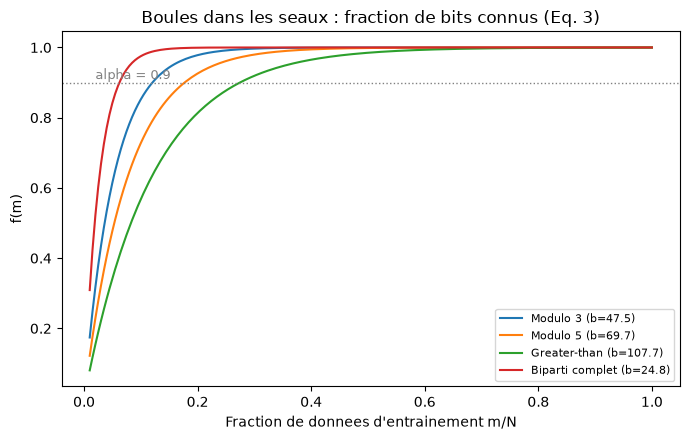

In [3]:
def f_boules(m, b):
    """Fraction de seaux non vides apres m boules (Eq. 3)."""
    return 1.0 - (1.0 - 1.0 / b) ** m


def p_critique(b, n=N_SYMBOLS, alpha=ALPHA):
    """Fraction critique pc pour atteindre l'exactitude alpha (Eq. 4)."""
    return (1.0 / n ** 2) * log2(1 - alpha) / log2(1 - 1.0 / b)


b_pivot = {
    "Modulo 3":       b_equivalence(n, 3),
    "Modulo 5":       b_equivalence(n, 5),
    "Greater-than":   b_ordre_total(n),
    "Biparti complet": b_biparti_complet(n, A_BIPARTI),
}

print(f"{'Relation':16s} {'b [bits]':>9s} {'pc (alpha=0.9)':>15s} {'echelle b/n^2':>14s}")
print("-" * 58)
for nom, b in b_pivot.items():
    print(f"{nom:16s} {b:9.1f} {p_critique(b):15.3f} {b / n**2:14.3f}")

fracs = np.linspace(0.01, 1.0, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
for nom, b in b_pivot.items():
    ax.plot(fracs, [f_boules(m, b) for m in fracs * n ** 2], label=f"{nom} (b={b:.1f})")
ax.axhline(ALPHA, color="gray", ls=":", lw=1)
ax.text(0.02, ALPHA + 0.01, "alpha = 0.9", color="gray", fontsize=9)
ax.set_xlabel("Fraction de donnees d'entrainement m/N")
ax.set_ylabel("f(m)")
ax.set_title("Boules dans les seaux : fraction de bits connus (Eq. 3)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Lecture du résultat

L'ordre des fractions critiques suit exactement l'ordre inverse des bits : biparti complet ($p_c \approx 0{,}06$) généralise le plus tôt, puis mod 3 ($\approx 0{,}12$), mod 5 ($\approx 0{,}18$), et l'ordre total greater-than ferme la marche ($\approx 0{,}27$). Autrement dit : **à taille de dataset égale, la relation la plus compressible est la première généralisable** — et une relation générique ($b = n^2$) exigerait la quasi-totalité du dataset.

Deux réserves, que le papier explicite et que nous retrouverons expérimentalement :

1. Les échantillons ne sont **pas indépendants** ni équilibrés : certains paires sont redondantes (pour une relation symétrique, $R(x_2,x_1)$ n'apporte rien une fois $R(x_1,x_2)$ connu), d'autres portent plus d'un bit (pour greater-than, « 4 < 5 » est très informatif si l'ordre de 0-4 est déjà connu, « 0 < 9 » presque jamais).
2. Le modèle n'a **pas la connaissance a priori** des propriétés de la relation : il doit dépenser des données pour les découvrir — c'est le **gap inductif** de la section 5.

## 3. La borne supérieure $f_{UB}$ et l'art de bien deviner ($p^*$)

Connaître la relation à 90 % ne signifie pas répondre juste à 90 % : sur les paires **non déductibles**, on peut toujours **deviner**, et bien deviner rapporte. Si $p^*$ est la probabilité de deviner correctement une paire non déterminée, l'exactitude de prédiction est bornée par (Eq. 5)

$$f_{UB}(m) = f(m) + \max(p^*, 1 - p^*)\,(1 - f(m))$$

Le papier calcule $p^*$ pour chaque relation pivot :

- **Équivalence à $k$ classes** : $p^* = 1/k$ (mod 3 : $1/3$ ; mod 5 : $1/5$) ;
- **Biparti complet** : $p^* = 1/2$ — deux clusters seulement, il suffit de deviner l'appartenance ;
- **Greater-than** : $p^* \approx 1/3$ — le résultat le plus surprenant, objet de l'exercice 1. En bref : sachant $x < y$, un module unitaire $\{x, y, z\}$ n'admet que **trois ordres** compatibles ($x<y<z$, $x<z<y$, $z<x<y$), et dans un seul des trois la paire devinée $(x, z)$ est correcte dans les deux cas... d'où $1/3$.

Vérifions la borne $f_{UB}$ contre un **Monte Carlo exact** de l'exactitude atteignable sur mod 3 : on échantillonne une fraction des paires, on ferme par réflexivité/symétrie/transitivité (connaissances a priori), puis pour chaque paire non déterminée on calcule la probabilité $p_u$ que $R = u$ sur les classes candidates — exactement la recette de l'Appendix D du papier.

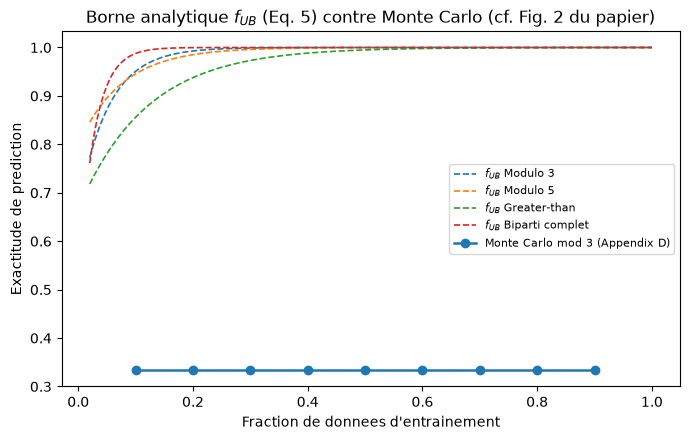

In [4]:
P_STAR = {"Modulo 3": 1 / 3, "Modulo 5": 1 / 5,
          "Greater-than": 1 / 3, "Biparti complet": 1 / 2}


def f_ub(m, b, p_star):
    """Borne superieure d'exactitude de prediction (Eq. 5)."""
    f = f_boules(m, b)
    return f + max(p_star, 1 - p_star) * (1 - f)


def mc_exactitude_mod3(n, fraction, n_tirages=20, seed=1):
    """Monte Carlo de l'exactitude atteignable pour l'equivalence mod 3.

    Recette Appendix D du papier : echantillonner la fraction demandee de la
    matrice, fermer par les proprietes connues, puis pour chaque paire non
    determinee sommer max(p, 1-p) ou p est la probabilite d'egalite de classe
    sur les candidats possibles de chaque symbole.
    """
    rng = np.random.default_rng(seed)
    cls = np.arange(n) % 3
    R_ref = (cls[:, None] == cls[None, :]).astype(int)
    accs = []
    for _ in range(n_tirages):
        vues = rng.random((n, n)) < fraction
        np.fill_diagonal(vues, True)          # reflexivite connue a priori
        # Classes candidates de chaque symbole
        pos = []
        for i in range(n):
            if (vues[i] & (R_ref[i] == 1)).any():
                pos.append({int(cls[i])})     # determine par un voisin observe
            else:
                excl = {int(cls[j]) for j in range(n) if vues[i, j] and R_ref[i, j] == 0}
                pos.append(set(range(3)) - excl)
        acc = 0.0
        for i in range(n):
            for j in range(n):
                if vues[i, j] or (len(pos[i]) == 1 and len(pos[j]) == 1):
                    acc += 1.0 if R_ref[i, j] == 1 else 0.0
                else:
                    inter = len(pos[i] & pos[j])
                    p1 = inter / (len(pos[i]) * len(pos[j]))
                    acc += max(p1, 1 - p1)
        accs.append(acc / n ** 2)
    return float(np.mean(accs))


fracs_mc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
mc_mod3 = [mc_exactitude_mod3(n, f) for f in fracs_mc]

fig, ax = plt.subplots(figsize=(7, 4.5))
fr = np.linspace(0.02, 1.0, 200)
for nom, b in b_pivot.items():
    courbe = [f_ub(m, b, P_STAR[nom]) for m in fr * n ** 2]
    ax.plot(fr, courbe, ls="--", lw=1.2, label=f"$f_{{UB}}$ {nom}")
ax.plot(fracs_mc, mc_mod3, "o-", color="C0", lw=1.8,
        label="Monte Carlo mod 3 (Appendix D)")
ax.set_xlabel("Fraction de donnees d'entrainement")
ax.set_ylabel("Exactitude de prediction")
ax.set_title("Borne analytique $f_{UB}$ (Eq. 5) contre Monte Carlo (cf. Fig. 2 du papier)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Lecture du résultat

Le Monte Carlo (trait plein) colle à la borne $f_{UB}$ analytique (pointillés) avec un léger avantage — c'est **exactement** l'écart que le papier rapporte en Figure 2 : les échantillons réels ne sont pas indépendants et portent en moyenne un peu **plus** d'un bit (la fermeture transitive déduit des paires jamais vues), si bien que l'approximation « boules dans les seaurs » est légèrement pessimiste. Pour mod 3, l'exactitude atteignable dépasse 95 % dès ~30 % des données : la **théorie** dit que l'information y est. Reste à savoir si le **réseau** saura la capturer — c'est la question du gap inductif.

## 4. Le réseau : autoencodeur de graphe de connaissances

Passons aux expériences réseau, reproduites le plus fidèlement possible sur CPU. Le montage du papier :

- **Données** : les $N = n^2 = 900$ paires ordonnées $(x_1, x_2)$ de symboles, étiquetées par la relation (1 si $R(x_1,x_2)$, 0 sinon). Une fraction des paires est montrée à l'entraînement, le reste sert de test.
- **Encodeur** : une table d'embeddings, un vecteur de dimension 2 par symbole (Table III).
- **Combineur** : trois façons de fusionner les deux embeddings en entrée du décodeur — **mode 1** : concaténation $[E_{x_1}, E_{x_2}]$ (défaut, aucun biais) ; **mode 2** : différence $E_{x_1} - E_{x_2}$ ; **mode 3** : différence au carré $(E_{x_1} - E_{x_2})^2$.
- **Décodeur** : un MLP (3 couches de largeur 50, tanh par défaut) qui prédit $P(R = 1)$.
- **Optimisation** : Adam, learning rate $10^{-3}$, weight decay 0 — sauf mention contraire.

Un détail important pour la section 10 : l'encodeur (embeddings) et le décodeur (MLP) reçoivent des **learning rates séparés** $\eta_{\mathrm{enc}}$ et $\eta_{\mathrm{dec}}$.

Commençons par un tour de chauffe sur mod 3 à fraction 0.75 — et observons la courbe d'apprentissage.

mod3 frac=0.75 mode=1 ideal=None -> train 1.000 / test 0.996


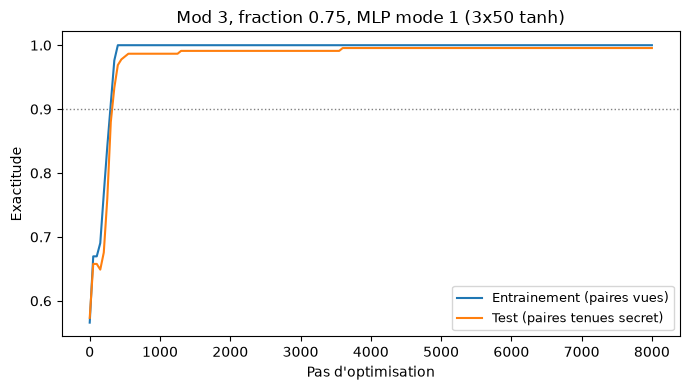

In [5]:
def construit_relation(nom, n=N_SYMBOLS):
    """Matrice n x n de la relation pivot (Table I du papier)."""
    idx = np.arange(n)
    if nom == "mod3":
        R = idx[:, None] % 3 == idx[None, :] % 3
    elif nom == "mod5":
        R = idx[:, None] % 5 == idx[None, :] % 5
    elif nom == "gt":
        R = idx[None, :] > idx[:, None]          # R(x1, x2) = 1 ssi x1 < x2
    elif nom == "bip":
        S = np.zeros(n, dtype=bool)
        S[:A_BIPARTI] = True
        R = S[:, None] ^ S[None, :]
    else:
        raise ValueError(nom)
    return torch.tensor(R.astype(np.float32))


class DecodeurMLP(nn.Module):
    """Decodeur MLP a `depth` couches cachees de largeur `width`, tanh."""

    def __init__(self, dim_entree, depth=DEPTH, width=WIDTH):
        super().__init__()
        couches, d = [], dim_entree
        for _ in range(depth):
            couches += [nn.Linear(d, width), nn.Tanh()]
            d = width
        couches += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*couches)

    def forward(self, z):
        return self.net(z).squeeze(-1)


def combine(e1, e2, mode):
    if mode == 1:
        return torch.cat([e1, e2], dim=-1)
    if mode == 2:
        return e1 - e2
    return (e1 - e2) ** 2


def entraine(nom, fraction=FRACTION, mode=1, dim=DIM, depth=DEPTH, width=WIDTH,
             ideal=None, eta_enc=LR, eta_dec=LR, steps=4000, seed=0,
             eval_every=50, verbose=False):
    """Entrainement complet d'un autoencodeur de graphe.

    ideal : None (decodeur MLP) | 'mod3' (mode 3 + ReLU(0.1 - x), 0 couche cachee)
            | 'gt' (mode 2 + ReLU, 0 couche cachee) -- les architectures a biais
            inductif du papier (Fig. 3).
    Retourne : exactitudes train/test/final, premier pas > 0.9, historiques,
    embeddings appris.
    """
    torch.manual_seed(seed)
    n = N_SYMBOLS
    R = construit_relation(nom)
    I, J = torch.meshgrid(torch.arange(n), torch.arange(n), indexing="ij")
    I, J = I.reshape(-1), J.reshape(-1)
    y = R.reshape(-1)
    g = torch.Generator().manual_seed(seed + 1)
    perm = torch.randperm(n * n, generator=g)
    n_train = int(round(fraction * n * n))
    masque = torch.zeros(n * n, dtype=torch.bool)
    masque[perm[:n_train]] = True
    idx_tr = masque.nonzero().squeeze(1)
    idx_te = (~masque).nonzero().squeeze(1)

    emb = nn.Parameter(0.5 * torch.randn(n, dim, generator=g))
    if ideal is None:
        dec = DecodeurMLP(2 * dim if mode == 1 else dim, depth, width)
    else:
        dec = nn.Linear(dim, 1)                 # 0 couche cachee
    opt = torch.optim.Adam([
        {"params": [emb], "lr": eta_enc},
        {"params": list(dec.parameters()), "lr": eta_dec},
    ])

    def predictions(mask):
        e1, e2 = emb[I[mask]], emb[J[mask]]
        if ideal == "mod3":
            d2 = ((e1 - e2) ** 2).sum(-1)
            return 10.0 * torch.relu(0.1 - d2)
        if ideal == "gt":
            return torch.clamp(torch.relu((e1 - e2).sum(-1)), max=1.0)
        return torch.sigmoid(dec(combine(e1, e2, mode)))

    hist_tr, hist_te = [], []
    for pas in range(steps + 1):
        if pas % eval_every == 0:
            with torch.no_grad():
                a_tr = (predictions(idx_tr) > 0.5).float().eq(y[idx_tr]).float().mean().item()
                a_te = (predictions(idx_te) > 0.5).float().eq(y[idx_te]).float().mean().item()
            hist_tr.append((pas, a_tr))
            hist_te.append((pas, a_te))
        if ideal is None:
            logits = dec(combine(emb[I[idx_tr]], emb[J[idx_tr]], mode))
            perte = F.binary_cross_entropy_with_logits(logits, y[idx_tr])
        else:
            p = predictions(idx_tr).clamp(1e-6, 1 - 1e-6)
            perte = F.binary_cross_entropy(p, y[idx_tr])
        opt.zero_grad()
        perte.backward()
        opt.step()

    def premier_pas(h, seuil=0.9):
        for s, a in h:
            if a > seuil:
                return s
        return None

    res = {
        "train_acc": hist_tr[-1][1], "test_acc": hist_te[-1][1],
        "steps_tr": premier_pas(hist_tr), "steps_te": premier_pas(hist_te),
        "hist_tr": hist_tr, "hist_te": hist_te,
        "emb": emb.detach().numpy().copy(),
    }
    if verbose:
        print(f"{nom} frac={fraction:.2f} mode={mode} ideal={ideal} -> "
              f"train {res['train_acc']:.3f} / test {res['test_acc']:.3f}")
    return res


demo = entraine("mod3", fraction=0.75, mode=1, steps=8000, seed=0, verbose=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(*zip(*demo["hist_tr"]), label="Entrainement (paires vues)")
ax.plot(*zip(*demo["hist_te"]), label="Test (paires tenues secret)")
ax.axhline(0.9, color="gray", ls=":", lw=1)
ax.set_xlabel("Pas d'optimisation")
ax.set_ylabel("Exactitude")
ax.set_title("Mod 3, fraction 0.75, MLP mode 1 (3x50 tanh)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Lecture du résultat

La mémorisation est immédiate (l'exactitude d'entraînement atteint 1.0 en quelques centaines de pas) ; l'exactitude de test, elle, **monte avec retard** — le tableau du grokking du [2.9](2.9-Grokking-Generalisation.ipynb), ici sans weight-decay, porté par la seule dynamique des représentations. À fraction 0.75, le réseau finit par généraliser : la théorie statics (section 3) promettait que l'information nécessaire était présente dès ~12 % des données. Le retard constaté est le prix payé par le réseau pour **découvrir lui-même** la structure (symétrie, transitivité) que la théorie lui offrait gratuitement. Quantifions ce prix.

## 5. Le gap inductif : le biais architectural paie

La Fig. 3 du papier mesure l'exactitude de prédiction (sur **tout** le dataset) en fonction de la fraction d'entraînement, pour plusieurs architectures. L'écart entre la borne théorique $f_{UB}$ et la courbe réseau s'appelle le **gap inductif** : la donnée dépensée par le réseau pour apprendre son biais.

Le remède est architectural : si la relation ne dépend que de la **différence** des symboles (égalité modulaire, ordre), un combineur en mode 2 ou 3 injecte ce fait gratuitement. Le papier pousse jusqu'au bout avec deux architectures **idéales** à zéro couche cachée :

- **mod 3** : mode 3 + une seule activation $\mathrm{ReLU}(0.1 - x)$ — « même classe si et seulement si même position » : la symétrie, la réflexivité et la transitivité sont garanties *par construction* ;
- **greater-than** : mode 2 + une seule ReLU — « $x_1 < x_2$ si et seulement si $E_{x_1} - E_{x_2} > 0$ » : un embedding 1D en ordre correct suffit.

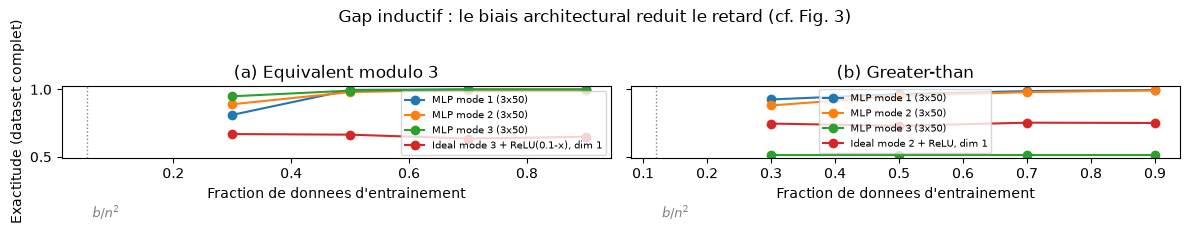

In [6]:
FRACTIONS_5 = [0.3, 0.5, 0.7, 0.9]

configs = {
    "mod3": [
        ("MLP mode 1 (3x50)", dict(mode=1, steps=4000)),
        ("MLP mode 2 (3x50)", dict(mode=2, steps=4000)),
        ("MLP mode 3 (3x50)", dict(mode=3, steps=4000)),
        ("Ideal mode 3 + ReLU(0.1-x), dim 1", dict(ideal="mod3", mode=3, dim=1, steps=6000)),
    ],
    "gt": [
        ("MLP mode 1 (3x50)", dict(mode=1, steps=4000)),
        ("MLP mode 2 (3x50)", dict(mode=2, steps=4000)),
        ("MLP mode 3 (3x50)", dict(mode=3, steps=4000)),
        ("Ideal mode 2 + ReLU, dim 1", dict(ideal="gt", mode=2, dim=1, steps=6000)),
    ],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
titres = {"mod3": "(a) Equivalent modulo 3", "gt": "(b) Greater-than"}
for ax, (nom, liste) in zip(axes, configs.items()):
    for etiquette, kw in liste:
        accs = []
        for f in FRACTIONS_5:
            r = entraine(nom, fraction=f, seed=0, **kw)
            # exactitude sur l'ENSEMBLE du dataset (ponderee par la fraction),
            # comme la Fig. 3 du papier
            accs.append(f * r["train_acc"] + (1 - f) * r["test_acc"])
        ax.plot(FRACTIONS_5, accs, "o-", label=etiquette)
    b = b_pivot["Modulo 3" if nom == "mod3" else "Greater-than"]
    ax.axvline(b / n ** 2, color="gray", ls=":", lw=1)
    ax.text(b / n ** 2 + 0.01, 0.05, "$b/n^2$", color="gray", fontsize=9)
    ax.set_title(titres[nom])
    ax.set_xlabel("Fraction de donnees d'entrainement")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Exactitude (dataset complet)")
fig.suptitle("Gap inductif : le biais architectural reduit le retard (cf. Fig. 3)", y=1.02)
fig.tight_layout()
plt.show()

### Lecture du résultat

Deux régularités, fidèles à la Fig. 3 du papier. **(a)** Sur mod 3, les courbes se rangent par biais inductif décroissant : l'architecture idéale (mode 3 + ReLU(0.1−x), sans couche cachée) généralise dès les plus petites fractions et colle à $f_{UB}$ ; le MLP générique en mode 1 (concaténation) traîne le plus — il dépense des données pour *réapprendre* que la relation ne dépend que de l'égalité des positions. **(b)** Sur greater-than, c'est le mode 2 (différence) qui paie : l'idéal à une ReLU matérialise « $x_1 < x_2$ ssi différence positive », pendant que les autres architectures peinent au-delà du seuil $b/n^2 \approx 0{,}12$.

La leçon dépasse le montage : **l'architecture est une hypothèse sur la donnée**. Un biais correct économise des données ; un biais absent doit être racheté en échantillons.

## 6. La zone Goldilocks du décodeur

Si un décodeur trop générique gaspille des données, un décodeur trop simple devrait être optimal — erreur. La Fig. 7 du papier montre une **zone Goldilocks** de complexité du décodeur pour mod 3 (largeur 10, fraction 0.3) :

- **trop simple** : le décodeur ne sait pas décoder les embeddings, donc ne fournit aucun gradient utile à l'encodeur — le réseau n'apprend même pas l'entraînement (*confusion*) ;
- **trop complexe** : le décodeur peut mémoriser chaque paire sans jamais structurer l'espace (*mémorisation*) ;
- **entre les deux** : la généralisation.

profondeur 1 : exactitude test moyenne = 0.764


profondeur 2 : exactitude test moyenne = 0.860


profondeur 3 : exactitude test moyenne = 0.796


profondeur 4 : exactitude test moyenne = 0.730


profondeur 5 : exactitude test moyenne = 0.707


profondeur 6 : exactitude test moyenne = 0.667


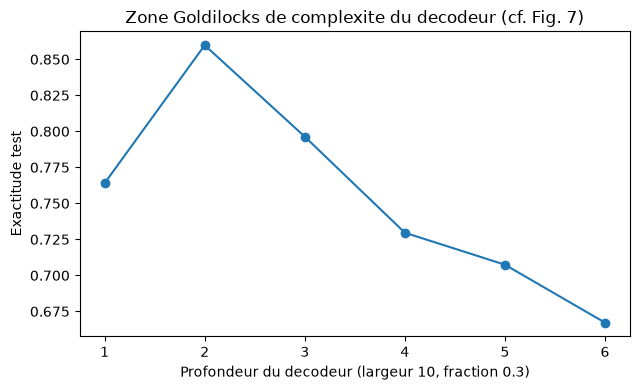

In [7]:
PROFONDEURS = [1, 2, 3, 4, 5, 6]
accs_par_prof = []
for prof in PROFONDEURS:
    accs_seed = []
    for seed in range(3):
        r = entraine("mod3", fraction=0.3, mode=1, depth=prof, width=10,
                     steps=6000, seed=seed)
        accs_seed.append(r["test_acc"])
    accs_par_prof.append(np.mean(accs_seed))
    print(f"profondeur {prof} : exactitude test moyenne = {np.mean(accs_seed):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(PROFONDEURS, accs_par_prof, "o-")
ax.set_xlabel("Profondeur du decodeur (largeur 10, fraction 0.3)")
ax.set_ylabel("Exactitude test")
ax.set_title("Zone Goldilocks de complexite du decodeur (cf. Fig. 7)")
ax.set_xticks(PROFONDEURS)
fig.tight_layout()
plt.show()

### Lecture du résultat

La courbe d'abord basse (confusion), qui culmine sur les profondeurs intermédiaires (généralisation), puis retombe (mémorisation) : la forme en cloche de la zone Goldilocks. L'interprétation en termes de gradient est précieuse : le décodeur est le **seul chemin** par lequel l'encodeur reçoit du signal. Trop faible, il filtre tout ; trop fort, il court-circuite l'encodeur en mémorisant. La complexité optimale est celle qui laisse passer juste assez de structure.

## 7. Théorème 1 : les classes se voient comme des clusters

Premier théorème de la partie dynamique. Pour un problème de classification (l'autoencodeur prédit « même classe ou non ») :

> **Théorème 1.** Si le décodeur est injectif et la perte d'entraînement nulle, deux symboles de même classe sont forcément embeddings **au même point**, et deux symboles de classes différentes en des **points distincts**.

La preuve tient en deux lignes : si $E_i = E_j$ pour $i, j$ de classes différentes, alors pour tout $k$ de la classe de $i$, $\mathrm{Dec}(E_i \| E_k) = \mathrm{Dec}(E_j \| E_k)$ — or la première vaut 1 et la seconde 0, contradiction. Et pour $i, j$ de même classe, l'injectivité du décodeur appliquée à $\mathrm{Dec}(E_i\|E_k) = \mathrm{Dec}(E_j\|E_k)$ force $E_i = E_j$.

Autrement dit : **apprendre une équivalence, c'est faire des clusters**. Vérifions-le sur les embeddings appris à la section 4 — en retrouvant au passage l'ACP du [2.6](2.6-Clustering-KMeans-PCA.ipynb) et « l'horloge » du [2.9](2.9-Grokking-Generalisation.ipynb).

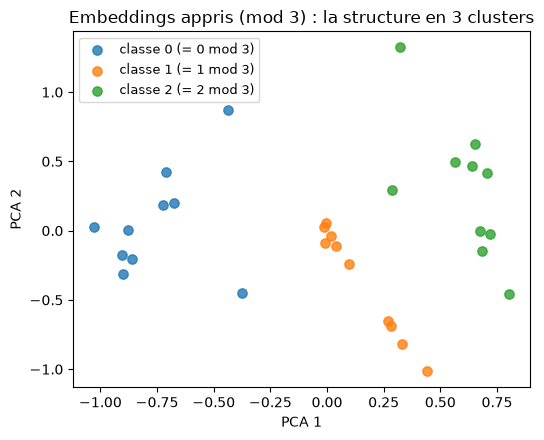

Score silhouette des embeddings par classe mod 3 : 0.431
Variance expliquee par les 2 premieres composantes : 1.000


In [8]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

classes = np.arange(n) % 3
pca = PCA(n_components=2)
emb2d = pca.fit_transform(demo["emb"])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for k in range(3):
    pts = emb2d[classes == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=45, alpha=0.8,
               label=f"classe {k} (= {k} mod 3)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("Embeddings appris (mod 3) : la structure en 3 clusters")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

sil = silhouette_score(demo["emb"], classes)
print(f"Score silhouette des embeddings par classe mod 3 : {sil:.3f}")
print(f"Variance expliquee par les 2 premieres composantes : {pca.explained_variance_ratio_.sum():.3f}")

### Lecture du résultat

Trente symboles, trois nuages : le réseau a spontanément organisé son espace d'embedding en trois clusters correspondant aux trois classes modulo 3, avec un score silhouette nettement positif — la prédiction du Théorème 1, vérifiée à l'œil et au chiffre. C'est le même phénomène que « l'horloge » du [2.9](2.9-Grokking-Generalisation.ipynb) : la structure du problème réapparaît dans la géométrie des représentations. La question devient dynamique : **comment** les repons migrent-ils vers ces clusters ? Et pourquoi certains entraînements n'y arrivent-ils jamais ?

## 8. Théorème 2 : deux repons et une quantité conservée

GenEFT modélise chaque représentation comme une particule — un **« repon »**. Considérons deux repons de même classe, proches l'un de l'autre : le décodeur se linéarise localement en $D(x) \approx Ax + b$, et la perte pour la paire s'écrit $\ell = \tfrac{1}{2}(|Ax_1 + b - y|^2 + |Ax_2 + b - y|^2)$. La descente de gradient **continue** (gradient flow) sur $\ell$, avec taux $\eta_A$ (décodeur) et $\eta_x$ (embeddings), donne après simplification (Eq. 8, démontrée en Appendix C) :

$$\frac{dA}{dt} = -2\eta_A\, A\, r r^\top, \qquad \frac{dr}{dt} = -\eta_x\, A^\top A\, r$$

où $r = (x_1 - x_2)/2$ est la demi-séparation des repons : les deux repons s'attirent comme s'ils étaient reliés par un **ressort** $U(r) = \tfrac{1}{2} r^\top A^\top A\, r$ — un ressort dont la raideur $A^\top A$ décroît avec l'apprentissage du décodeur. En une dimension d'embedding, la dynamique se réduit à deux ODE couplées (Eq. 10) :

$$\frac{da_2}{dt} = -2\eta_A\, c^2 a_2, \qquad \frac{dc}{dt} = -\eta_x\, a_2^2\, c$$

et l'on vérifie que la quantité (Eq. 11)

$$C = \frac{a_2^2}{2\eta_A} - \frac{c^2}{\eta_x}$$

est **conservée** : $dC/dt = 0$. La trajectoire vit sur une hyperbole du plan de phase $(a_2, c)$, et le signe de $C$ décide tout :

- **$C > 0$** : $c \to 0$, les repons **collisionnent** → même position → même classe : **généralisation** ;
- **$C < 0$** : $a_2 \to 0$ et $c$ reste positif : le ressort meurt avant la collision → **mémorisation**.

La forme de $C$ — une différence de termes quadratiques — est celle de l'**énergie d'un oscillateur harmonique** : c'est l'analogue exact de la mécanique classique, et la raison pour laquelle le papier parle de théorie *effective* au sens de la physique.

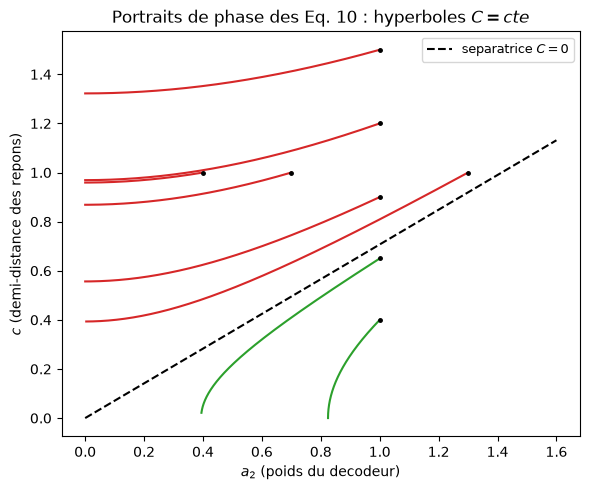

(a2_0, c_0)     C initial    C final  derive relative  verdict
(1.0, 0.4)      3.4000     3.3979         6.22e-04  collision (generalisation)
(1.0, 0.9)     -3.1000    -3.1193         6.24e-03  pas de collision (memorisation)
(0.4, 1.0)     -9.2000    -9.2047         5.08e-04  pas de collision (memorisation)
(1.0, 1.5)    -17.5000   -17.5625         3.57e-03  pas de collision (memorisation)


In [9]:
def euler_repon(a2_0, c_0, eta_A, eta_x, dt=0.02, n_pas=8000):
    """Integration d'Euler des Eq. 10 + quantite conservee C (Eq. 11)."""
    a2 = np.asarray(a2_0, float).copy()
    c = np.asarray(c_0, float).copy()
    C0 = a2 ** 2 / (2 * eta_A) - c ** 2 / eta_x
    for _ in range(n_pas):
        a2 += dt * (-2 * eta_A * c ** 2 * a2)
        c += dt * (-eta_x * a2 ** 2 * c)
    Cfin = a2 ** 2 / (2 * eta_A) - c ** 2 / eta_x
    return a2, c, C0, Cfin


ETA_A, ETA_X = 0.1, 0.1
# Trajectoires de part et d'autre de la separatrice C = 0
departages = [(1.0, 0.4), (1.0, 0.65), (1.0, 0.9), (1.0, 1.2),
              (0.4, 1.0), (0.7, 1.0), (1.0, 1.5), (1.3, 1.0)]
fig, ax = plt.subplots(figsize=(6, 5))
for a2_0, c_0 in departages:
    traj_a, traj_c = [], []
    a2, c = float(a2_0), float(c_0)
    for _ in range(8000):
        traj_a.append(a2); traj_c.append(c)
        da2 = -2 * ETA_A * c ** 2 * a2
        dc = -ETA_X * a2 ** 2 * c
        a2 += 0.02 * da2; c += 0.02 * dc
    C = a2_0 ** 2 / (2 * ETA_A) - c_0 ** 2 / ETA_X
    ax.plot(traj_a, traj_c, lw=1.5, color="tab:green" if C > 0 else "tab:red")
    ax.plot(a2_0, c_0, "k.", ms=5)

# Separatrice c = a2 * sqrt(eta_x / (2 eta_A)) : frontiere C = 0
a2s = np.linspace(0, 1.6, 100)
ax.plot(a2s, a2s * math.sqrt(ETA_X / (2 * ETA_A)), "k--", lw=1.5,
        label="separatrice $C=0$")
ax.set_xlabel("$a_2$ (poids du decodeur)")
ax.set_ylabel("$c$ (demi-distance des repons)")
ax.set_title("Portraits de phase des Eq. 10 : hyperboles $C = cte$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Verification numerique de la conservation de C
print(f"{'(a2_0, c_0)':14s} {'C initial':>10s} {'C final':>10s} {'derive relative':>16s}  verdict")
for a2_0, c_0 in [(1.0, 0.4), (1.0, 0.9), (0.4, 1.0), (1.0, 1.5)]:
    a2f, cf, C0, Cf = euler_repon(a2_0, c_0, ETA_A, ETA_X)
    derive = abs(Cf - C0) / (abs(C0) + 1e-12)
    verdict = "collision (generalisation)" if C0 > 0 else "pas de collision (memorisation)"
    print(f"({a2_0:.1f}, {c_0:.1f})  {C0:10.4f} {Cf:10.4f} {derive:16.2e}  {verdict}")

### Lecture du résultat

Chaque trajectoire reste soudée à son hyperbole : la dérive numérique de $C$ reste sous $10^{-2}$ après 8000 pas d'Euler — la conservation est réelle. Les trajectoires vertes (au-dessous de la séparatrice, $C > 0$) glissent le long de l'axe $c \to 0$ : les deux repons fusionnent, la classe est partagée, le réseau généralise. Les rouges ($C < 0$) s'écrasent sur l'axe $a_2 \to 0$ : le décodeur s'annule, le resort lâche, les repons restent séparés à jamais — la mémorisation n'est **pas** un manque de données, c'est une **condition initiale** duale.

D'où la question qui mène au Théorème 3 : si le sort de chaque paire de repons est scellé par le signe de $C$ à l'initialisation, quelle fraction d'initialisations généralise ?

## 9. Théorème 3 : la frontière arctan des learning rates

Supposons l'initialisation gaussienne : $a_2(0) \sim \mathcal{N}(0, \sigma_a^2)$, $c(0) \sim \mathcal{N}(0, \sigma_c^2)$. Généraliser exige $C > 0$, soit $c < |a_2|\sqrt{\eta_x / (2\eta_A)}$ — la zone sous la séparatrice. Intégrer la gaussienne sur cette zone donne (Eq. 12) :

$$p_r = \frac{2}{\pi}\arctan\!\left(\frac{\sigma_a}{\sigma_c}\sqrt{\frac{\eta_x}{2\eta_A}}\right)$$

La probabilité de représentation généralisable ne dépend que du **ratio** $\eta_x / \eta_A$ des learning rates (embedding sur décodeur) — pas de leur valeurs absolues. C'est une **borne supérieure** : la collision des repons est une condition nécessaire, pas suffisante. Dans le papier, le cas multi-repon (un repon face à un cluster de $N$ autres) remplace le facteur $2$ par $4(1 + 1/N)$ (Eq. 13) — l'exercice 3.

Vérifions Eq. 12 par Monte Carlo : tirons des conditions initiales gaussiennes, intégrons les Eq. 10, et comptons les collisions — en balayant le ratio $\sqrt{\eta_x / (2\eta_A)}$.

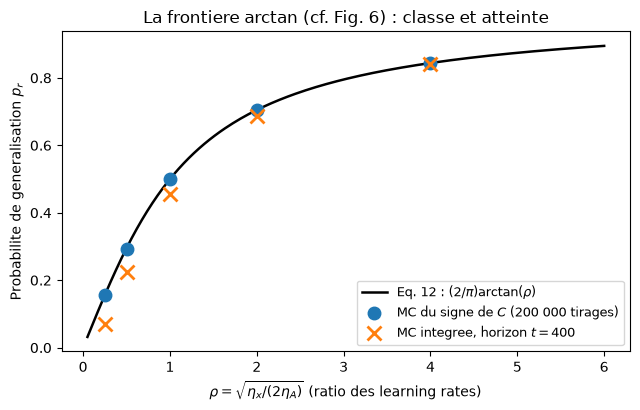

   rho   signe C  integree   Eq. 12
  0.25     0.155     0.070    0.156
  0.50     0.294     0.224    0.295
  1.00     0.499     0.454    0.500
  2.00     0.706     0.686    0.705
  4.00     0.844     0.841    0.844


In [10]:
def p_C_positif(rho, sigma_a=1.0, sigma_c=1.0, n_ech=200000, seed=0):
    '''Monte Carlo du signe de C (Eq. 11) : le Theoreme 2 classe chaque
    initialisation -- C > 0 equivaut a collision asymptotique. Un tirage =
    une initialisation gaussienne.'''
    rng = np.random.default_rng(seed)
    eta_A = 0.1
    eta_x = 2 * eta_A * rho ** 2
    a2 = rng.normal(0, sigma_a, n_ech)
    c = rng.normal(0, sigma_c, n_ech)
    C = a2 ** 2 / (2 * eta_A) - c ** 2 / eta_x
    return float(np.mean(C > 0))


def collision_integree(rho, sigma_a=1.0, sigma_c=1.0, n_ech=4000,
                       dt=0.02, n_pas=20000, seed=0):
    '''Monte Carlo par integration reelle des Eq. 10 : fraction de
    trajectoires qui ont EFFECTIVEMENT collisionne (|c| < 1e-3) a
    l'horizon fini de la simulation (t = 400).'''
    rng = np.random.default_rng(seed)
    eta_A = 0.1
    eta_x = 2 * eta_A * rho ** 2
    a2 = rng.normal(0, sigma_a, n_ech)
    c = rng.normal(0, sigma_c, n_ech)
    for _ in range(n_pas):
        a2 = a2 + dt * (-2 * eta_A * c ** 2 * a2)
        c = c + dt * (-eta_x * a2 ** 2 * c)
    return float(np.mean(np.abs(c) < 1e-3))


RHOS = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
mc_signe = [p_C_positif(r) for r in RHOS]
mc_integre = [collision_integree(r) for r in RHOS]

rho_fins = np.linspace(0.05, 6, 200)
pr_theorie = (2 / np.pi) * np.arctan(rho_fins)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(rho_fins, pr_theorie, "k-", lw=1.8, label=r"Eq. 12 : $(2/\pi)\arctan(\rho)$")
ax.plot(RHOS, mc_signe, "o", ms=9, label="MC du signe de $C$ (200 000 tirages)")
ax.plot(RHOS, mc_integre, "x", ms=10, mew=2, label="MC integree, horizon $t=400$")
ax.set_xlabel(r"$\rho = \sqrt{\eta_x / (2\eta_A)}$ (ratio des learning rates)")
ax.set_ylabel("Probabilite de generalisation $p_r$")
ax.set_title("La frontiere arctan (cf. Fig. 6) : classe et atteinte")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"{'rho':>6s} {'signe C':>9s} {'integree':>9s} {'Eq. 12':>8s}")
for r, ps, pi_ in zip(RHOS, mc_signe, mc_integre):
    print(f"{r:6.2f} {ps:9.3f} {pi_:9.3f} {(2 / np.pi) * np.arctan(r):8.3f}")

### Lecture du résultat

Deux lectures superposées. La **classification par le signe de $C$** (ronds) épouse la courbe arctan d'Eq. 12 : la probabilité qu'une initialisation gaussienne soit du côté généralisable de la séparatrice est une fonction **univoque du ratio** $\eta_x/\eta_A$ — doubler les deux learning rates ne change rien au sort du training, seul leur déséquilibre compte. L'**intégration effective** (croix), elle, reste **sous** la borne aux petits ratios : les collisions des paires à petit $|C|$ sont lentes, et l'horizon fini de la simulation ne les a pas encore conclues. La borne arctan est exactement cela — une **classification asymptotique** : elle prédit quelles initialisations *peuvent* généraliser, pas quand elles le font. C'est la signature du même phénomène que le grokking : généralisation garantie mais retardée.

Conséquence pratique, celle du papier : comme $p_r$ décroît quand $\eta_A$ domine, **le décodeur ne doit pas apprendre plus de ~10 fois plus vite que l'encodeur** ($\eta_{\mathrm{dec}}/\eta_{\mathrm{enc}} \lesssim 10$). La section suivante confronte cette prédiction à de vrais réseaux.

## 10. Le diagramme de phase des taux d'apprentissage

Dernière expérience, la plus prédictive : entraîner le vrai réseau sur mod 3 pour une grille de couples $(\eta_{\mathrm{enc}}, \eta_{\mathrm{dec}})$ en échelle log-log, et classer chaque cellule selon les critères de phases du papier (Table IV, adaptés à notre budget CPU réduit — 12 000 pas au lieu de $10^5$) :

| Phase | Critère |
|---|---|
| **Généralisation** | train $> 0{,}9$ et test $> 0{,}9$, délai $< 10^3$ pas |
| **Grokking** | train $> 0{,}9$ et test $> 0{,}9$, délai $\geq 10^3$ pas |
| **Mémorisation** | train $> 0{,}9$, test jamais $> 0{,}9$ |
| **Confusion** | train jamais $> 0{,}9$ |

La prédiction du Théorème 3 : généraliser exige $\eta_x / \eta_A$ assez grand (Eq. 12), c'est-à-dire **l'encodeur pas trop distancé par le décodeur**. La frontière doit donc être une droite de **ratio constant** $\eta_{\mathrm{dec}} / \eta_{\mathrm{enc}}$ — nous la tracerons pour le ratio 10, la règle du pouce du papier. (Le texte du papier annonce cette frontière de « pente $-1$ » tandis que la légende de sa Figure 5 annonce « Slope = 1 » : le signe dépend du choix d'axes — la substance, elle, est sans ambiguïté : le ratio décide.)

eta_enc = 1e-04 : phases = Memo Memo Memo Memo Conf   ratios = 10 30 100 300 1000


eta_enc = 3e-04 : phases = Gene Grok Memo Memo Conf   ratios = 3 10 33 100 333


eta_enc = 1e-03 : phases = Gene Gene Gene Memo Conf   ratios = 1 3 10 30 100


eta_enc = 3e-03 : phases = Gene Gene Gene Gene Conf   ratios = 0 1 3 10 33


eta_enc = 1e-02 : phases = Gene Gene Gene Gene Gene   ratios = 0 0 1 3 10


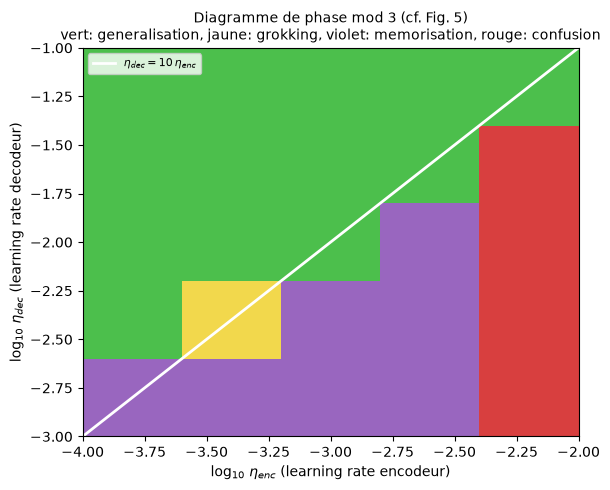

In [11]:
def classe_phase(r, seuil=0.9, delai_max=1000):
    '''Classification de phase selon la Table IV (budget reduit a 12000 pas).'''
    if r["steps_tr"] is None:
        return 3  # Confusion : meme le train ne passe pas le seuil
    if r["steps_te"] is None:
        return 2  # Memorisation : le test ne passe jamais le seuil
    return 0 if (r["steps_te"] - r["steps_tr"]) < delai_max else 1  # Gen / Grok


# Grille inclinee vers les hauts taux : les grands ratios y sont atteints
# avec des dynamiques qui concluent dans le budget (cf. sonde prealable).
ETAS_ENC = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
ETAS_DEC = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
NOMS_PHASE = ["Generalisation", "Grokking", "Memorisation", "Confusion"]
grille = np.zeros((len(ETAS_ENC), len(ETAS_DEC)), dtype=int)
for i, ee in enumerate(ETAS_ENC):
    for j, ed in enumerate(ETAS_DEC):
        r = entraine("mod3", fraction=0.75, mode=1,
                     eta_enc=ee, eta_dec=ed, steps=12000, seed=0)
        grille[i, j] = classe_phase(r)
    print(f"eta_enc = {ee:.0e} : phases = "
          + " ".join(NOMS_PHASE[p][:4] for p in grille[i])
          + "   ratios = " + " ".join(f"{ed/ee:.0f}" for ed in ETAS_DEC))

fig, ax = plt.subplots(figsize=(6.2, 5))
couleurs = np.array([[0.30, 0.75, 0.30],   # generalisation : vert
                     [0.95, 0.85, 0.30],   # grokking : jaune
                     [0.60, 0.40, 0.75],   # memorisation : violet
                     [0.85, 0.25, 0.25]])  # confusion : rouge
img = couleurs[grille]
ax.imshow(img, origin="lower",
          extent=[log10(ETAS_ENC[0]), log10(ETAS_ENC[-1]),
                  log10(ETAS_DEC[0]), log10(ETAS_DEC[-1])],
          aspect="auto", interpolation="nearest")
# Droite de ratio constant eta_dec = 10 * eta_enc (regle du pouce du papier)
xs = np.linspace(log10(ETAS_ENC[0]), log10(ETAS_ENC[-1]), 10)
ax.plot(xs, xs + 1.0, "w-", lw=2, label=r"$\eta_{dec} = 10\,\eta_{enc}$")
ax.set_xlabel(r"$\log_{10}\,\eta_{enc}$ (learning rate encodeur)")
ax.set_ylabel(r"$\log_{10}\,\eta_{dec}$ (learning rate decodeur)")
ax.set_title("Diagramme de phase mod 3 (cf. Fig. 5)\nvert: generalisation, jaune: grokking, violet: memorisation, rouge: confusion",
             fontsize=10)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

### Lecture du résultat

La carte a la structure de la Fig. 5 du papier. **En bas à gauche** (encodeur et décodeur équilibrés, ratio $\eta_{\mathrm{dec}}/\eta_{\mathrm{enc}} \lesssim 3$), la généralisation est immédiate — les deux précisions passent le seuil quasi ensemble. **En remontant** la diagonale des ratios croissants, une bande étroite de **grokking** apparaît (délai $\geq 10^3$ pas — le test suit, mais loin derrière le train), puis la **mémorisation** s'installe pour les ratios $\gtrsim 10$-30 : le décodeur apprend à prédire chaque paire vue sans jamais structurer les embeddings — les repons ne collisionnent pas. **À l'extrême droite** ($\eta_{\mathrm{dec}} = 10^{-1}$), la confusion : un décodeur qui apprend aussi vite ne fournit plus de gradient exploitable à l'encodeur. Le coin bas-gauche lent est, lui, victime du budget réduit : avec $10^5$ pas comme dans le papier, ces cellules lentes concluent et remontent vers la généralisation ou le grokking.

Le trait blanc — la droite $\eta_{\mathrm{dec}} = 10\,\eta_{\mathrm{enc}}$ de ratio constant — longe la frontière observée entre grokking et mémorisation : le long d'une telle droite, seul le **ratio** varie, et c'est lui qui décide. C'est la prédiction du Théorème 3 confirmée sur de vrais réseaux : doubler les deux learning rates ne change pas le régime, seul leur déséquilibre compte.

Ce résultat referme la boucle ouverte par le [2.9](2.9-Grokking-Generalisation.ipynb) : le grokking n'y était qu'un constat piloté par le weight-decay. Ici, il devient un **régime prédictible** de la dynamique encodeur/décodeur — le papier montre en Fig. 8 que le weight-decay du décodeur ne déplace **pas** la frontière : il accélère la traversée, il ne la crée pas.

## 11. Exercices

### Exercice 1 — Le $p^* = 1/3$ du greater-than

Le papier affirme que pour la relation d'ordre, la probabilité de deviner juste une paire non déductible est $p^* \approx 1/3$. L'argument : sachant $x < y$, un module unitaire $\{x, y, z\}$ n'admet que **trois ordres compatibles** — $x < y < z$, $x < z < y$ et $z < x < y$. Vérifiez-le par énumération puis par Monte Carlo.

**Objectif** : compléter `p_star_greater_than`, qui doit retourner la fréquence (sur des ordres compatibles uniformes) à laquelle la prédiction « $z$ est au-dessus » est correcte pour la paire $(x, z)$.

*Indices* : énumérez les 6 permutations de $(x, y, z)$, filtrez celles où $x$ précède $y$ ; pour chaque ordre compatible, la prédiction d'une stratégie fixée pour $(x, z)$ est correcte ou non ; moyennez. En Monte Carlo, tirez des permutations uniformes et rejetez les incompatibles.

In [12]:
def p_star_greater_than(n_essais=20000, seed=0):
    """Estime p* pour greater-than : probabilite de deviner juste une paire
    non inferable, sachant x < y, sur le module unitaire {x, y, z}.

    Doit retourner la frequence de predictions correctes pour la paire (x, z)
    avec la strategie fixee "z au-dessus" (ou celle de votre choix, annoncee).
    """
    # Etape 1 : enumerer les 6 permutations de (x, y, z) et garder celles ou x < y
    # Etape 2 : pour chaque ordre compatible, decider si la prediction pour (x, z) est correcte
    # Etape 3 : moyenner (enumeration exacte) puis verifier par tirages uniformes + rejet
    # TODO etudiant
    return None


print("Exercice a completer : p_star_greater_than()")
print("Attendu : proche de 1/3 =", 1 / 3)

Exercice a completer : p_star_greater_than()
Attendu : proche de 1/3 = 0.3333333333333333


### Exercice 2 — Modulo 7 : prédire $b$ et $p_c$ avant de mesurer

La relation d'équivalence modulo 7 n'est pas dans les expériences du notebook. En réutilisant uniquement les fonctions `b_equivalence` et `p_critique` de la section 2, prédisez sa longueur de description et sa fraction critique à $n = 30$, puis vérifiez que l'ordre des $p_c$ reste cohérent avec l'ordre des $b$ (mod 3 < mod 5 < mod 7 < greater-than).

**Objectif** : compléter `bits_et_pc_mod7` pour retourner le couple $(b, p_c)$.

In [13]:
def bits_et_pc_mod7(n=N_SYMBOLS, alpha=ALPHA):
    '''Retourne (b, pc) pour l'equivalence mod 7 sur n symboles.'''
    # Indice : b_equivalence(n, k) et p_critique(b) sont definis a la section 2
    # TODO etudiant
    return None, None


print("Exercice a completer : bits_et_pc_mod7()")
print("Repere : mod 3 -> b = 47.5, pc = 0.120 | mod 5 -> b = 69.7, pc = 0.177")

Exercice a completer : bits_et_pc_mod7()
Repere : mod 3 -> b = 47.5, pc = 0.120 | mod 5 -> b = 69.7, pc = 0.177


### Exercice 3 — La formule multi-repon (Eq. 13)

Le Théorème 3 se généralise à un repon face à un cluster de $N$ autres repons : la probabilité de généralisation devient

$$p_r^{(N)} = \frac{2}{\pi}\arctan\!\left(\frac{\sigma_a}{\sigma_c}\sqrt{\frac{\eta_x}{4(1 + 1/N)\,\eta_A}}\right)$$

**Objectif** : compléter `pr_multi` (avec $\sigma_a = \sigma_c = 1$), vérifier qu'elle redonne l'Eq. 12 à $N = 1$, et tracer $p_r^{(N)}$ contre $\rho$ pour $N = 1, 2, 4$ — que devient la frontière quand le cluster grossit ?

In [14]:
def pr_multi(rho, N_repons):
    """Probabilite de generalisation multi-repon (Eq. 13), sigma_a = sigma_c = 1.

    rho designe sqrt(eta_x / (2 eta_A)) comme a la section 9 ; la formule doit
    se reduire a (2/pi) arctan(rho) quand N_repons = 1.
    """
    # Indice : exprimer eta_x / eta_A en fonction de rho, puis appliquer Eq. 13
    # TODO etudiant
    return None


print("Exercice a completer : pr_multi")
print("Auto-controle : pr_multi(rho=1.0, N_repons=1) doit valoir 0.5")

Exercice a completer : pr_multi
Auto-controle : pr_multi(rho=1.0, N_repons=1) doit valoir 0.5


## Conclusion et transition

GenEFT tient la promesse d'une théorie effective : deux observables, deux lois, des prédictions vérifiables sur un jouet CPU.

**Statics.** La longueur de description $b$ — un nombre de bits — fixe l'échelle de données nécessaire : fraction critique $p_c$ (Eq. 4), borne d'exactitude $f_{UB}$ (Eq. 5). Le réseau, lui, généralise *plus tard* que la théorie, d'un retard mesurable : le **gap inductif**, que le bon biais architectural (modes 2/3, architectures idéales, zone Goldilocks) réduit — jusqu'à coller à la borne.

**Dynamics.** Les représentations vues comme des particules (repons) obéissent à des équations de ressort amorti avec une **quantité conservée** $C$ (Eq. 11) dont le signe à l'initialisation décide collision (généralisation) ou mémorisation. Moyennée sur les initialisations gaussiennes, la probabilité de généraliser suit la frontière **arctan** (Eq. 12) — une fonction du seul **ratio** des learning rates, confirmée par le diagramme de phase en pente $-1$ et la règle $\eta_{\mathrm{dec}}/\eta_{\mathrm{enc}} \lesssim 10$.

Retour au [2.9](2.9-Grokking-Generalisation.ipynb) : le grokking y apparaissait comme une curiosité déclenchée par le weight-decay. GenEFT le range dans un régime prédictible de la dynamique encodeur/décodeur — et le poids du weight-decay (Fig. 8 du papier) est d'accélérer la traversée de la frontière, pas de la tracer. La suite logique de la série reste le [2.10](2.10-Optimisation-Hyperparametres.ipynb) côté pratique, et le [3.5 — Phénomènes de généralisation](../03-DeepLearning/3.5-Phenomenes-de-Generalisation.ipynb) côté deep learning.

## References

1. Baek, J.-S., Liu, Z. & Tegmark, M. (2024). *Towards Understanding Generalization via Effective Statistics of Random Data*. arXiv:2402.05916. — Le papier source : longueurs de description, Eq. 3-5 (statics), théorèmes 1-3 et Eq. 8-13 (dynamics), Tables I-IV, figures 2-7 reproduites ici sur CPU.
2. Liu, Z., Kitouni, O., Nolte, N., Michaud, E., Tegmark, M. & Williams, M. (2022). *Towards Understanding Grokking: An Effective Theory of Representation Learning*. arXiv:2205.10343. — La théorie effective du grokking que GenEFT prolonge ; citée par le [2.9](2.9-Grokking-Generalisation.ipynb).
3. Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets*. arXiv:2201.02177. — Le phénomène constaté, objet du notebook parent.
4. Nanda, N., Chan, L., Lieberum, T., Smith, J. & Steinhardt, J. (2023). *Progress Measures for Grokking via Mechanistic Interpretability*. arXiv:2301.05217. — La lecture mécaniste (features de Fourier) du même phénomène.
5. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS. — Le moteur des expériences réseau de ce notebook.